In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
R1 = 1e3  # Ohms
R2 = 1e3  # Ohms
R3 = 1e3  # Ohms
R4 = 1e3  # Ohms
R5 = 1e3  # Ohms
R6 = 1e3  # Ohms
R7 = 1e3  # Ohms
C6 = 1e-6  # Farads
RV1 = 10e3  # Ohms (Potentiometer 1 maximum value)
RV2 = 10e3  # Ohms (Potentiometer 2 maximum value)

# Frequency range for analysis
frequencies = np.logspace(0, 6, 1000)  # 1 Hz to 1 MHz

In [82]:

def voltage_reference_buffer_gain(Vin, RV1_position):
    """
    Voltage Reference Buffer Stage (U2A).
    """
    Vref = Vin * (RV1_position / RV1)  # Voltage from potentiometer
    gain = 1  # Voltage follower (buffer) has a gain of 1
    Vout = Vref * gain
    return Vout, gain

def differential_amplifier_gain(Vin, Vref):
    """
    Differential Amplifier Stage (U2B).
    """
    # Gain of differential amplifier
    gain = (R6 / R5)
    Vout = gain * (Vin - Vref)
    return Vout, gain

def adjustable_gain_amplifier(Vin, RV2_position):
    """
    Adjustable Gain Amplifier Stage (U2C).
    """
    # Gain of inverting amplifier with feedback potentiometer
    gain = (R6 + RV2_position) / RV2_position
    Vout = gain * Vin
    return Vout, gain

def low_pass_filter_gain(Vin, freq):
    """
    Low-Pass Filter and Buffer Stage (U2D).
    """
    # Cut-off frequency calculation
    fc = 1 / (2 * np.pi * R7 * C6)
    # Gain of low-pass filter (in decimal)
    gain = 1 / np.sqrt(1 + (freq / fc) ** 2)
    Vout = gain * Vin
    return Vout, gain

# Parameter Inputs

In [83]:
# Assume input signal amplitude is 1V
Vin = 2.6

# Input signal voltage to buffer
Vref = 5.0

# Define positions of potentiometers (normalized 0 to 1)
RV1_ratio = 0.5  # 50% of the potentiometer
RV2_ratio = 0.01  # 50% of the potentiometer

## Intermediate Calculations

In [84]:

# Calculate the position of the potentiometers
RV1_position = RV1_ratio * RV1
RV2_position = RV2_ratio * RV2

# Calculate each stage
Vout_stage1, gain_stage1 = voltage_reference_buffer_gain(Vref, RV1_position)
Vout_stage2, gain_stage2 = differential_amplifier_gain(Vin, Vout_stage1)  # Use Vout_stage1 as reference
Vout_stage3, gain_stage3 = adjustable_gain_amplifier(Vout_stage2, RV2_position)

# Calculate the low-pass filter gain for all frequencies
Vout_stage4, gains_stage4 = zip(*[low_pass_filter_gain(Vout_stage3, f) for f in frequencies])

# Convert gains to array
gains_stage4 = np.array(gains_stage4)

# Calculate cumulative gain in decimal
cumulative_gain_decimal = gain_stage1 * gain_stage2 * gain_stage3 * gains_stage4

# Convert cumulative gain to dB
cumulative_gain_db = 20 * np.log10(abs(cumulative_gain_decimal))

# Find cutoff frequency and maximum gain
cutoff_frequency = 1 / (2 * np.pi * R7 * C6)
max_gain_decimal = np.max(cumulative_gain_decimal)
max_gain_db = np.max(cumulative_gain_db)

# Results

Set Reference Voltage (RV1): 2.50 V
Input Signal Voltage: 2.60 V
Output Voltage at 1 Hz: 1.10 V


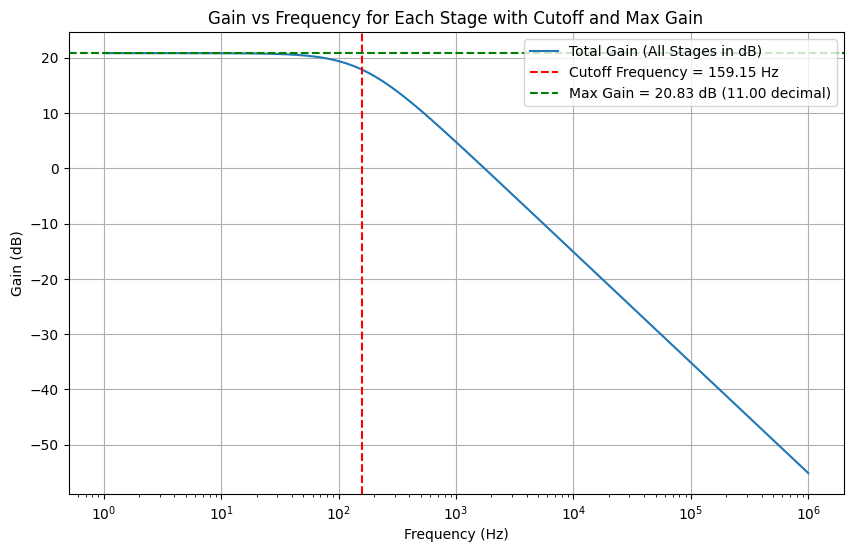

In [85]:


# Print the set reference voltage using RV1
print(f"Set Reference Voltage (RV1): {Vout_stage1:.2f} V")

# Print the input signal voltage
print(f"Input Signal Voltage: {Vin:.2f} V")

# Print the output voltage after all stages
print(f"Output Voltage at 1 Hz: {Vout_stage4[0]:.2f} V")  # Use the first value from the list of output voltages of stage 4

plt.figure(figsize=(10, 6))
plt.semilogx(frequencies, cumulative_gain_db, label="Total Gain (All Stages in dB)")
plt.axvline(cutoff_frequency, color='r', linestyle='--', label=f'Cutoff Frequency = {cutoff_frequency:.2f} Hz')
plt.axhline(max_gain_db, color='g', linestyle='--', label=f'Max Gain = {max_gain_db:.2f} dB ({max_gain_decimal:.2f} decimal)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.title('Gain vs Frequency for Each Stage with Cutoff and Max Gain')
plt.legend()
plt.grid()
plt.show()